# Conhecendo a base de dados

## Importando os dados


In [ ]:
import pandas as pd
url= 'https://raw.githubusercontent.com/alura-cursos/pandas-conhecendo-a-biblioteca/main/base-de-dados/aluguel.csv'
data= pd.read_csv(url, sep=';')

In [43]:
data.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN


In [44]:
data.tail()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
32955,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0
32958,Apartamento,Leblon,2,0,0,70,3000.0,760.0,NaN
32959,Conjunto Comercial/Sala,Centro,0,0,0,250,6500.0,4206.0,1109.0


In [45]:
type(data)

pandas.DataFrame

## Características gerais da base de dados

In [46]:
data.shape

(32960, 9)

In [47]:
data.columns

Index(['Tipo', 'Bairro', 'Quartos', 'Vagas', 'Suites', 'Area', 'Valor',
       'Condominio', 'IPTU'],
      dtype='str')

In [48]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32960 entries, 0 to 32959
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        32960 non-null  str    
 1   Bairro      32960 non-null  str    
 2   Quartos     32960 non-null  int64  
 3   Vagas       32960 non-null  int64  
 4   Suites      32960 non-null  int64  
 5   Area        32960 non-null  int64  
 6   Valor       32943 non-null  float64
 7   Condominio  28867 non-null  float64
 8   IPTU        22723 non-null  float64
dtypes: float64(3), int64(4), str(2)
memory usage: 2.3 MB


In [49]:
data['Tipo']

0                      Quitinete
1                           Casa
2        Conjunto Comercial/Sala
3                    Apartamento
4                    Apartamento
                  ...           
32955                  Quitinete
32956                Apartamento
32957                Apartamento
32958                Apartamento
32959    Conjunto Comercial/Sala
Name: Tipo, Length: 32960, dtype: str

In [50]:
data[['Quartos','Valor',]]

,Quartos,Valor
0,1,1700.0
1,2,7000.0
2,0,5200.0
3,1,800.0
4,1,800.0
...,...,...
32955,0,800.0
32956,3,1800.0
32957,2,1400.0
32958,2,3000.0


# Análise exploratória de dados

## Qual o valor médio de aluguel por tipo de imóvel?

<Axes: title={'center': 'Valor médio de aluguel por tipo de imóvel'}, xlabel='Tipo'>

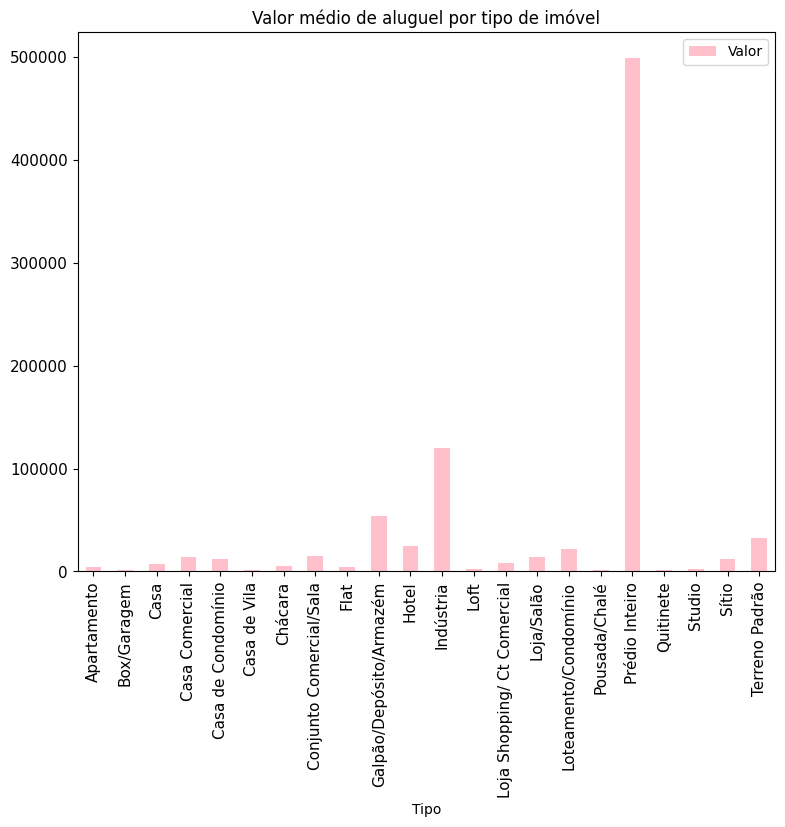

In [51]:
df_aluguel_valor_tipo= data.groupby('Tipo')[['Valor']].mean().sort_values('Tipo')
df_aluguel_valor_tipo.plot.bar(title= 'Valor médio de aluguel por tipo de imóvel', figsize=(9,7), fontsize='11', color='pink')

In [ ]:
df_aluguel_valor_tipo.describe()

## Removendo os imóveis comerciais

In [52]:
data.Tipo.unique()

<StringArray>
[                  'Quitinete',                        'Casa',
     'Conjunto Comercial/Sala',                 'Apartamento',
          'Casa de Condomínio',              'Prédio Inteiro',
                        'Flat',                  'Loja/Salão',
     'Galpão/Depósito/Armazém',              'Casa Comercial',
                'Casa de Vila',              'Terreno Padrão',
                 'Box/Garagem',                        'Loft',
 'Loja Shopping/ Ct Comercial',                     'Chácara',
       'Loteamento/Condomínio',                       'Sítio',
               'Pousada/Chalé',                      'Studio',
                       'Hotel',                   'Indústria']
Length: 22, dtype: str

In [53]:
imoveis_comerciais = [
  'Conjunto Comercial/Sala', 
  'Prédio Inteiro', 'Loja/Salão', 
  'Galpão/Depósito/Armazém', 
  'Casa Comercial', 'Terreno Padrão',
  'Loja Shopping/ Ct Comercial',
  'Box/Garagem', 'Chácara',
  'Loteamento/Condomínio', 'Sítio',
  'Pousada/Chalé', 'Hotel', 'Indústria'
]

In [54]:
imoveis_nao_comerciais= data.query('@imoveis_comerciais not in Tipo')
df= imoveis_nao_comerciais
df.Tipo.unique()

<StringArray>
[         'Quitinete',               'Casa',        'Apartamento',
 'Casa de Condomínio',               'Flat',       'Casa de Vila',
               'Loft',             'Studio']
Length: 8, dtype: str

In [55]:
df_aluguel_valor_tipo = df.groupby('Tipo')[['Valor']].mean().sort_values('Valor')
df_aluguel_valor_tipo


,Valor
Tipo,
Quitinete,1246.840909
Casa de Vila,1574.369478
Studio,2400.000000
Loft,2557.882353
Flat,4546.189076
Apartamento,4744.614648
Casa,6793.454922
Casa de Condomínio,11952.061245


## Qual o percentual de cada tipo de imóvel na nossa base de dados?

In [56]:
df.Tipo.value_counts()

Tipo
Apartamento           19532
Casa de Condomínio      996
Casa                    967
Quitinete               836
Flat                    476
Casa de Vila            249
Loft                     51
Studio                    4
Name: count, dtype: int64

In [ ]:
df_percentual_tipo = df.Tipo.value_counts(normalize=True).to_frame().sort_values('Tipo')
df_percentual_tipo

,proportion
Tipo,
Apartamento,0.845139
Casa,0.041842
Casa de Condomínio,0.043096
Casa de Vila,0.010774
Flat,0.020596
Loft,0.002207
Quitinete,0.036173
Studio,0.000173


<Axes: xlabel='Tipos', ylabel='Percentual'>

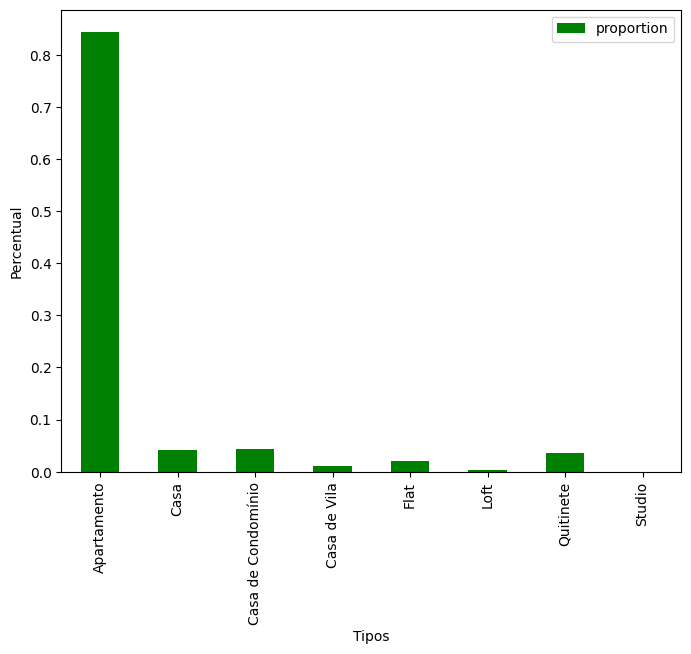

In [58]:
df_percentual_tipo.plot(kind='bar', figsize=(8,6), color='green', xlabel='Tipos', ylabel='Percentual')

In [ ]:
df = df.query('Tipo == "Apartamento"')
df

,Percetuais,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0
10,Apartamento,Centro,1,0,0,36,1200.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
32951,Apartamento,Vila Valqueire,2,0,0,52,1000.0,550.0,NaN
32953,Apartamento,Méier,2,0,0,70,900.0,490.0,48.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0


### **Selecionando apenas os imóveis do tipo apartamento**

# Tratando e filtrando os dados

## Lidando com dados nulos

## Removendo registros

## Filtros

### **1. Apartamentos que possuem `1 quarto` e `aluguel menor que 1200`**



### **2. `Apartamentos` que possuem pelo menos `2 quartos`, `aluguel menor que 3000` e `area maior que 70`**

## Salvando os dados

# Manipulando os dados

## Criando colunas numéricas

## Criando colunas categóricas